<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</center>
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Tecnicatura en Gestión de Datos (TGAD)**

---

## **Métodos Predictivos para la Gestión**
### **Trabajo Práctico Integrador**

---

**Dataset:** Colorado Real Estate 2026

**Fecha de entrega:** 10/06/2026

**Integrantes:**
1. Alexander Ballera - N° 919064
2. Alma Asmar - N° 919085
3. Alan Baez - N° 919129
4. Guadalupe Benitez - N° 919082

---

## INDICE DEL TRABAJO PRACTICO

1. [Carga y Configuracion Inicial](#carga)
2. [Preguntas Obligatorias](#preguntas-obligatorias)
   - Exploracion de la Identidad y el Contexto
   - Inventario y Tipologia de Variables
   - Identificacion de "Ruido" y Variables No Informativas
   - Definicion del Problema y Encuadre del Enfoque
3. [i) Seleccion de Datos y Preprocesamiento](#preprocesamiento)
4. [ii) Muestreo e Inferencia](#muestreo)
5. [iii) Modelado Estadistico Clasico](#modelado-estadistico)
6. [iv) Machine Learning y Validacion](#machine-learning)
7. [v) Conclusion Comparativa](#conclusion)

---

<a id="carga"></a>
## SECCION 0: Carga y Configuracion Inicial

En esta parte cargamos las librerias y abrimos el dataset.

### Importar librerías necesarias

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split

try:
    import kagglehub
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

### Cargar el dataset

In [2]:
DATASET = "kanchana1990/colorado-real-estate-market-2026"
DATA_FILE = "/colorado_real_estate_2026.csv"

DATA_PATH = kagglehub.dataset_download(DATASET) + DATA_FILE

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Archivo usado: {DATA_PATH}")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Using Colab cache for faster access to the 'colorado-real-estate-market-2026' dataset.
Archivo usado: /kaggle/input/colorado-real-estate-market-2026/colorado_real_estate_2026.csv
Filas: 8362 | Columnas: 11


### Vista preliminar de los datos

In [3]:
display(df.head(3))

print("\nTipos de datos:")
print(df.dtypes)

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,Beautifully maintained and spacious brick ranc...,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0
1,single_family,NaN,"$150, 000 PRICE CUT! And it still comes with a...",425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0
2,single_family,NaN,Located on a quiet cul-de-sac in the desirable...,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0



Tipos de datos:
type                object
sub_type            object
text                object
listPrice            int64
sqft               float64
stories            float64
beds               float64
baths              float64
baths_full         float64
baths_full_calc    float64
garage             float64
dtype: object


---
<a id="preguntas-obligatorias"></a>
## SECCION 1: Preguntas Obligatorias

Esta seccion responde a las preguntas obligatorias del trabajo practico antes de iniciar el analisis formal.

### 1.1 Exploración de la Identidad y el Contexto

Antes de modelar, ubicamos el problema en su contexto de negocio y de datos.
El objetivo es entender qué representa cada registro y cómo se construyó la base, para evitar conclusiones sin fundamento.

#### ¿Cuál es la fuente de los datos?

Describir: ¿Es una base gubernamental, un registro de una empresa, una simulación o una encuesta?

**Re:**
La fuente es el dataset público Colorado Real Estate Market 2026 en Kaggle.
Según la documentación, consolida publicaciones activas de plataformas inmobiliarias (Realtor, Zillow y Redfin), procesadas para análisis con Python/Pandas.

Se eliminaron errores críticos y duplicados exactos, pero se conservaron faltantes reales en variables secundarias para permitir ejercicios de imputación y modelado.

**URL de referencia:**
https://www.kaggle.com/datasets/kanchana1990/colorado-real-estate-market-2026

---
### 1.2 Inventario y Tipología de Variables

#### ¿Cuántas variables (columnas) tienen y de qué tipo son?

Clasificarlas en cualitativas (nominales/ordinales) y cuantitativas (discretas/continuas).

In [4]:
filas, columnas = df.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas.")

El dataset tiene 8362 filas y 11 columnas.


In [5]:
tipos_datos = df.dtypes.value_counts().rename_axis("tipo").reset_index(name="cantidad")
display(tipos_datos)

print("\nDetalle por columna:")
print(df.dtypes)

,tipo,cantidad
0,float64,7
1,object,3
2,int64,1



Detalle por columna:
type                object
sub_type            object
text                object
listPrice            int64
sqft               float64
stories            float64
beds               float64
baths              float64
baths_full         float64
baths_full_calc    float64
garage             float64
dtype: object


In [6]:
vars_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
vars_categoricas = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:")
print(vars_numericas)
print("\nVariables categóricas:")
print(vars_categoricas)

Variables numéricas:
['listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']

Variables categóricas:
['type', 'sub_type', 'text']


#### ¿Cuál es la variable "Target" (objetivo)?

Elegimos `listPrice` como variable objetivo porque representa el precio publicado de la propiedad y es numérica continua. Por eso el enfoque principal será de **regresión**.

In [7]:
target = "listPrice"
print(f"Variable objetivo: {target}")
print(f"Tipo de dato de target: {df[target].dtype}")
print("Enfoque del problema: Regresión")

Variable objetivo: listPrice
Tipo de dato de target: int64
Enfoque del problema: Regresión


#### ¿Qué rango tienen las variables numéricas?

A continuación mostramos mínimo y máximo por variable para ver diferencias de escala. Esto nos ayuda a decidir más adelante si conviene escalar o transformar variables.

In [8]:
rangos = df[vars_numericas].agg(["min", "max"]).T.rename(columns={"min": "valor_min", "max": "valor_max"})
display(rangos)

,valor_min,valor_max
listPrice,1.0,45000000.0
sqft,273.0,39558.0
stories,1.0,7.0
beds,0.0,48.0
baths,0.0,28.0
baths_full,1.0,28.0
baths_full_calc,1.0,28.0
garage,0.0,66.0


---
### 1.3 Identificación de "Ruido" y Variables No Informativas

**No todo lo que está en el dataset sirve para predecir.**

#### ¿Existen variables de identificación única?

Se revisa el porcentaje de valores únicos por columna. Si una variable tiene casi todos los valores distintos, puede comportarse como ID y no aportar capacidad de generalización al modelo.

In [9]:
umbral_id = 0.98
ratio_unicos = (df.nunique(dropna=False) / len(df)).sort_values(ascending=False)
ids_potenciales = ratio_unicos[ratio_unicos >= umbral_id]

print("Posibles variables de identificación (ratio de únicos >= 98%):")
if ids_potenciales.empty:
    print("No se detectaron variables con comportamiento de ID único.")
else:
    display(ids_potenciales.to_frame("ratio_unicos"))

Posibles variables de identificación (ratio de únicos >= 98%):
No se detectaron variables con comportamiento de ID único.


#### ¿Hay variables con varianza cero?

Si una variable siempre toma el mismo valor, no ayuda a explicar diferencias de precio y se considera no informativa para el modelo.

In [10]:
varianza_cero_num = [col for col in vars_numericas if df[col].nunique(dropna=False) <= 1]
varianza_cero_cat = [col for col in vars_categoricas if df[col].nunique(dropna=False) <= 1]

print("Variables numéricas con varianza cero:", varianza_cero_num)
print("Variables categóricas con un solo valor:", varianza_cero_cat)

Variables numéricas con varianza cero: []
Variables categóricas con un solo valor: []


#### ¿Existen variables redundantes?

Para variables numéricas usamos correlación alta como alerta de redundancia. Si dos columnas se mueven casi igual, evaluamos dejar solo una para evitar duplicar información.

In [11]:
corr_num = df[vars_numericas].corr(numeric_only=True)
pares_redundantes = (
    corr_num.where(np.triu(np.ones(corr_num.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pares_redundantes.columns = ["var_1", "var_2", "correlacion"]
pares_redundantes = pares_redundantes[pares_redundantes["correlacion"].abs() >= 0.85]

if pares_redundantes.empty:
    print("No se detectaron pares numéricos altamente correlacionados (|r| >= 0.85).")
else:
    display(pares_redundantes.sort_values("correlacion", key=np.abs, ascending=False))

,var_1,var_2,correlacion
23,baths,baths_full_calc,0.925159


#### ¿Qué porcentaje de datos faltantes (NaN) tiene cada columna?

Calculamos faltantes en porcentaje para decidir tratamiento: eliminar columna, imputar o conservar según impacto en el análisis.

In [12]:
faltantes = df.isna().mean().mul(100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0].round(2)

print("Porcentaje de faltantes por columna:")
if faltantes.empty:
    print("No hay faltantes.")
else:
    display(faltantes.to_frame("porcentaje_faltantes"))

Porcentaje de faltantes por columna:


,porcentaje_faltantes
sub_type,81.30
garage,45.67
stories,45.66
baths_full,31.02
baths_full_calc,28.62
sqft,28.52
beds,28.27
baths,15.31
text,0.47


In [13]:
if faltantes.empty:
    print("No hay columnas con faltantes para resumir.")
else:
    resumen_faltantes = faltantes.reset_index()
    resumen_faltantes.columns = ["columna", "porcentaje_faltantes"]
    display(resumen_faltantes)

,columna,porcentaje_faltantes
0,sub_type,81.30
1,garage,45.67
2,stories,45.66
3,baths_full,31.02
4,baths_full_calc,28.62
5,sqft,28.52
6,beds,28.27
7,baths,15.31
8,text,0.47


---
### 1.4 Definición del problema

**En esta parte convertimos los datos en una pregunta concreta de análisis.**

#### ¿Qué pregunta intentan responder con estos datos?

Ejemplo: "¿Podemos predecir el precio de una propiedad basándonos en sus características?"

**Re:**
La pregunta principal es: **¿qué variables explican mejor el precio de lista (`listPrice`) de una propiedad?**
El objetivo final es estimar precios con un modelo de regresión.

#### ¿Cuál es el "dolor" o la necesidad que resuelve su modelo?

¿Quién usaría esta información y para qué tomaría una decisión basada en ella?

**Re:**
Este modelo puede ayudar a inmobiliarias y propietarios a fijar precios de referencia más consistentes, y a compradores a evaluar si un precio publicado está razonable frente a propiedades comparables.

#### ¿Cuál es su hipótesis inicial?

¿Qué variables creen, a priori, que serán las más importantes para explicar el fenómeno?

**Re:**
Hipótesis inicial: el precio tendrá mayor relación con `sqft`, `baths`, `beds`, `stories` y `type`, porque resumen tamaño, comodidad y categoría del inmueble.

---
<a id="preprocesamiento"></a>
## SECCION 2: i) Seleccion de Datos y Preprocesamiento (Unidad 2)

### 2.1 Selección del Dataset

El dataset seleccionado es **colorado_real_estate_2026.csv** con información de propiedades inmobiliarias en Colorado.

**Fuente (Kaggle):**
https://www.kaggle.com/datasets/kanchana1990/colorado-real-estate-market-2026

**Ficha rápida del dataset:**
- 8,362 observaciones
- 11 variables
- Variable objetivo: `listPrice` (numérica) → enfoque de regresión

### Cómo vamos a leer la parte descriptiva

Para analizar los datos, vamos a mirar tres cosas en cada variable:

- Posición: media, mediana y percentiles
- Dispersión: rango, desvío estándar, RIQ y coeficiente de variación
- Forma: asimetría (G1) y comparación entre media y mediana

Regla simple que usaremos en el TP: si media > mediana y G1 > 0, la distribución tiene cola a la derecha y suele convenir usar la mediana como valor típico.

In [14]:
n_obs, n_vars = df.shape

print(f"Observaciones: {n_obs}")
print(f"Variables: {n_vars}")
print(f"Target: listPrice ({df['listPrice'].dtype})")

if n_obs >= 10000 and n_vars >= 10:
    print("El dataset cumple el mínimo de tamaño indicado.")
else:
    print("El dataset no llega al mínimo de 10,000 filas, pero se usa por ser el dataset oficial del TP.")

Observaciones: 8362
Variables: 11
Target: listPrice (int64)
El dataset no llega al mínimo de 10,000 filas, pero se usa por ser el dataset oficial del TP.


---
### 2.2 Limpieza de Datos

En esta sección identificamos y tratamos los problemas de calidad de datos.

#### 2.2.1 Identificación de valores faltantes

In [15]:
faltantes_abs = df.isna().sum().sort_values(ascending=False)
faltantes_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)

tabla_faltantes = pd.DataFrame({
    "faltantes": faltantes_abs,
    "porcentaje": faltantes_pct
})

display(tabla_faltantes[tabla_faltantes["faltantes"] > 0])

,faltantes,porcentaje
sub_type,6798,81.30
garage,3819,45.67
stories,3818,45.66
baths_full,2594,31.02
baths_full_calc,2393,28.62
sqft,2385,28.52
beds,2364,28.27
baths,1280,15.31
text,39,0.47


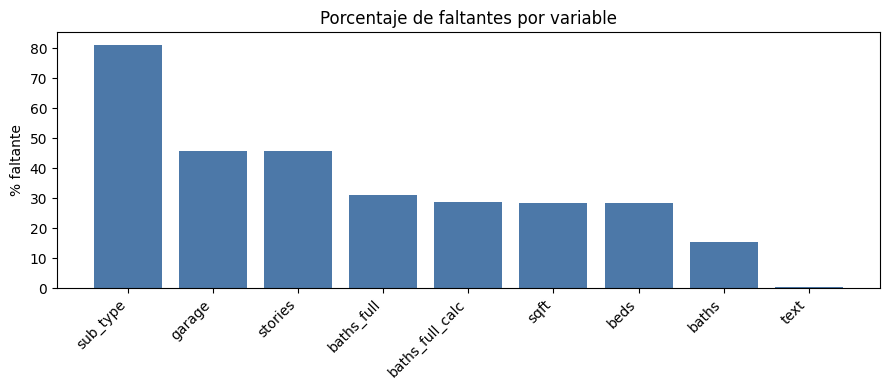

In [16]:
tabla_plot = tabla_faltantes[tabla_faltantes["faltantes"] > 0].copy()

plt.figure(figsize=(9, 4))
plt.bar(tabla_plot.index, tabla_plot["porcentaje"], color="#4C78A8")
plt.title("Porcentaje de faltantes por variable")
plt.ylabel("% faltante")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 2.2.2 Tratamiento de valores faltantes

Decisión: ¿imputación o eliminación? Justificar la estrategia elegida.

In [17]:
df_prep = df.copy()

# 1) Eliminamos variable con faltantes extremos
df_prep = df_prep.drop(columns=["sub_type"])

# 2) Texto faltante se completa con etiqueta simple
df_prep["text"] = df_prep["text"].fillna("sin_descripcion")

# 3) Imputación KNN para variables numéricas
cols_num = df_prep.select_dtypes(include=["number"]).columns.tolist()
imputer = KNNImputer(n_neighbors=5)
df_prep[cols_num] = imputer.fit_transform(df_prep[cols_num])

print("Columnas finales:", df_prep.columns.tolist())
print(f"Filas: {df_prep.shape[0]} | Columnas: {df_prep.shape[1]}")
print("Faltantes restantes:", int(df_prep.isna().sum().sum()))

Columnas finales: ['type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']
Filas: 8362 | Columnas: 10
Faltantes restantes: 0


**Decisiones de pretratamiento (faltantes):**

- `sub_type` se eliminó porque tenía faltantes muy altos y duplicaba información de `type` para este objetivo de regresión.
- `text` se completó con `sin_descripcion` para no perder registros; esa variable no es central en el modelo final.
- En variables numéricas usamos `KNNImputer` porque conserva mejor la estructura entre variables (por ejemplo, tamaño y baños) que una imputación por media.

**Conclusión de esta etapa:** priorizamos conservar observaciones útiles, reducir ruido y mantener coherencia para el modelado.

#### 2.2.3 Detección de valores atípicos (Outliers)

**Método 1: Boxplots (visualización)**

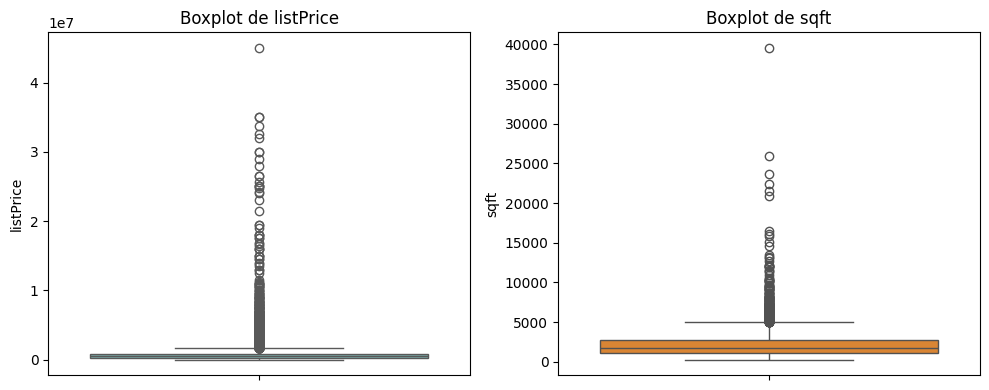

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(y=df_prep["listPrice"], ax=axes[0], color="#72B7B2")
axes[0].set_title("Boxplot de listPrice")

sns.boxplot(y=df_prep["sqft"], ax=axes[1], color="#F58518")
axes[1].set_title("Boxplot de sqft")

plt.tight_layout()
plt.show()

**Método 2: Regla de Tukey (RIQ)**

Outlier si: `x < Q1 - 1.5*RIQ` o `x > Q3 + 1.5*RIQ`

In [19]:
def detectar_outliers_tukey(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    return ((serie < li) | (serie > ls)).sum(), li, ls

In [20]:
cols_out = ["listPrice", "sqft", "beds", "baths", "garage"]

reporte_tukey = []
for c in cols_out:
    n_out, li, ls = detectar_outliers_tukey(df_prep[c])
    reporte_tukey.append({"variable": c, "outliers": int(n_out), "lim_inf": li, "lim_sup": ls})

reporte_tukey = pd.DataFrame(reporte_tukey).sort_values("outliers", ascending=False)
display(reporte_tukey)

,variable,outliers,lim_inf,lim_sup
0,listPrice,787,-5.725000e+05,1607500.000
4,garage,363,-2.220446e-16,3.200
1,sqft,362,-1.150625e+03,5016.375
3,baths,109,-2.000000e+00,6.000
2,beds,54,-1.000000e+00,7.000


**Método 3: Z-score**

Outlier si: `|z-score| > 3`

In [21]:
z_table = []
for c in cols_out:
    z = np.abs(stats.zscore(df_prep[c], nan_policy="omit"))
    z_table.append({"variable": c, "outliers_zscore": int((z > 3).sum())})

display(pd.DataFrame(z_table).sort_values("outliers_zscore", ascending=False))

,variable,outliers_zscore
0,listPrice,111
1,sqft,101
3,baths,59
4,garage,58
2,beds,53


#### 2.2.4 Tratamiento de outliers

Decisión: ¿conservar, eliminar o transformar? Justificar.

### ¿Por qué usamos `log_listPrice`?

- `listPrice` tiene una distribución muy sesgada: hay muchas propiedades en valores medios y pocas muy caras.
- Al aplicar `np.log1p(listPrice)` comprimimos los valores altos y hacemos más estable la variable para modelar.
- Esa transformación mejora el ajuste de la regresión lineal y reduce el peso de los extremos reales del mercado.
- Después, cuando predecimos, volvemos a dólares con `np.expm1(...)` para interpretar el precio original.

In [22]:
df_modelo = df_prep.copy()

# Eliminamos casos claramente erróneos
errores = (
    (df_modelo["listPrice"] <= 100)
    | (df_modelo["sqft"] < 200)
    | (df_modelo["beds"] < 0)
    | (df_modelo["baths"] < 0)
)

n_errores = int(errores.sum())
df_modelo = df_modelo[~errores].copy()

# Conservamos outliers estructurales y usamos transformación log para modelar mejor
df_modelo["log_listPrice"] = np.log1p(df_modelo["listPrice"])

print(f"Registros eliminados por error: {n_errores}")
print(f"Base después de limpieza de outliers erróneos: {df_modelo.shape}")

Registros eliminados por error: 10
Base después de limpieza de outliers erróneos: (8352, 11)


**Decisiones sobre outliers:**

- Detectamos extremos con boxplot, Tukey (RIQ) y z-score.
- No eliminamos todos los valores extremos porque en mercado inmobiliario pueden representar propiedades premium reales.
- Solo se removieron registros con señales de error de calidad (por ejemplo, precios o superficies claramente inconsistentes).
- Para estabilizar el ajuste sin perder casos reales, modelamos con `log_listPrice`.

**Criterio aplicado:** limpiar errores evidentes, conservar variabilidad real del negocio.

#### 2.2.5 Detección de duplicados

In [23]:
dup_total = int(df_modelo.duplicated().sum())
dup_texto = int(df_modelo.duplicated(subset=["text"]).sum())

print(f"Duplicados exactos: {dup_total}")
print(f"Registros con texto repetido: {dup_texto}")

Duplicados exactos: 0
Registros con texto repetido: 174


In [24]:
antes = len(df_modelo)
df_modelo = df_modelo.drop_duplicates().copy()
despues = len(df_modelo)

print(f"Filas antes: {antes}")
print(f"Filas después: {despues}")
print(f"Duplicados eliminados: {antes - despues}")

Filas antes: 8352
Filas después: 8352
Duplicados eliminados: 0


#### 2.2.6 Resolución de inconsistencias lógicas

Verificar coherencia entre variables relacionadas.

In [25]:
inconsistencias = (
    ((df_modelo["beds"] == 0) & (df_modelo["sqft"] > 1000))
    | ((df_modelo["baths"] == 0) & (df_modelo["sqft"] > 1000))
    | (df_modelo["garage"] > 20)
)

n_inconsistencias = int(inconsistencias.sum())
df_modelo = df_modelo[~inconsistencias].copy()

print(f"Inconsistencias detectadas: {n_inconsistencias}")
print(f"Tamaño final para análisis: {df_modelo.shape}")

Inconsistencias detectadas: 989
Tamaño final para análisis: (7363, 11)


---
### 2.3 Análisis Descriptivo

Realizar un estudio analítico descriptivo completo de las variables.

#### 2.3.1 Resumen estadístico general

In [26]:
resumen_general = df_modelo.describe().T
display(resumen_general)

,count,mean,std,min,25%,50%,75%,max
listPrice,7363.0,922565.978813,2.043893e+06,200.000000,318500.00000,517500.000000,815000.000000,4.500000e+07
sqft,7363.0,2217.836588,1.599168e+03,273.000000,1170.00000,1787.000000,2802.000000,3.955800e+04
stories,7363.0,1.630938,5.865596e-01,1.000000,1.00000,1.600000,2.000000,7.000000e+00
beds,7363.0,3.177210,1.470280e+00,0.000000,2.00000,3.000000,4.000000,4.800000e+01
baths,7363.0,2.594703,1.566766e+00,0.000000,2.00000,2.800000,3.000000,2.800000e+01
baths_full,7363.0,2.058319,1.142993e+00,1.000000,1.00000,2.000000,2.400000,2.800000e+01
baths_full_calc,7363.0,2.391770,1.212635e+00,1.000000,2.00000,2.000000,3.000000,2.800000e+01
garage,7363.0,2.005949,1.037673e+00,0.000000,1.40000,2.000000,2.000000,1.700000e+01
log_listPrice,7363.0,13.067295,1.166159e+00,5.303305,12.67138,13.156767,13.610945,1.762217e+01


#### 2.3.2 Medidas de Tendencia Central

##### Media (promedio aritmético)

In [27]:
display(df_modelo[cols_out].mean().to_frame("media"))

,media
listPrice,922565.978813
sqft,2217.836588
beds,3.177210
baths,2.594703
garage,2.005949


##### Mediana (percentil 50)

In [28]:
display(df_modelo[cols_out].median().to_frame("mediana"))

,mediana
listPrice,517500.0
sqft,1787.0
beds,3.0
baths,2.8
garage,2.0


##### Moda (valor más frecuente)

In [29]:
moda_simple = df_modelo[cols_out].mode().iloc[0].to_frame("moda")
display(moda_simple)

,moda
listPrice,450000.0
sqft,812.6
beds,3.0
baths,3.0
garage,2.0


#### 2.3.3 Medidas de Dispersión

##### Varianza

In [30]:
display(df_modelo[cols_out].var().to_frame("varianza"))

,varianza
listPrice,4.177497e+12
sqft,2.557339e+06
beds,2.161725e+00
baths,2.454756e+00
garage,1.076764e+00


##### Desvío estándar

In [31]:
display(df_modelo[cols_out].std().to_frame("desvio_std"))

,desvio_std
listPrice,2.043893e+06
sqft,1.599168e+03
beds,1.470280e+00
baths,1.566766e+00
garage,1.037673e+00


##### Rango

In [32]:
rango = (df_modelo[cols_out].max() - df_modelo[cols_out].min()).to_frame("rango")
display(rango)

,rango
listPrice,44999800.0
sqft,39285.0
beds,48.0
baths,28.0
garage,17.0


##### Rango Intercuartílico (RIQ)

In [33]:
riq = (df_modelo[cols_out].quantile(0.75) - df_modelo[cols_out].quantile(0.25)).to_frame("riq")
display(riq)

,riq
listPrice,496500.0
sqft,1632.0
beds,2.0
baths,1.0
garage,0.6


##### Coeficiente de Variación (CV)

In [34]:
cv = ((df_modelo[cols_out].std() / df_modelo[cols_out].mean()) * 100).to_frame("cv_pct")
display(cv)

,cv_pct
listPrice,221.544318
sqft,72.104875
beds,46.275828
baths,60.383248
garage,51.729768


#### 2.3.4 Medidas de Forma

##### Asimetría (Skewness)

In [35]:
display(df_modelo[cols_out].skew().to_frame("asimetria"))

,asimetria
listPrice,9.805883
sqft,4.672931
beds,6.409490
baths,2.359538
garage,4.256089


##### Curtosis (Kurtosis)

In [36]:
display(df_modelo[cols_out].kurtosis().to_frame("curtosis"))

,curtosis
listPrice,130.317010
sqft,62.241173
beds,148.374090
baths,23.467489
garage,37.222032


#### 2.3.5 Percentiles y Cuartiles

In [37]:
percentiles = df_modelo[cols_out].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).T
percentiles.columns = ["P10", "P25", "P50", "P75", "P90"]
display(percentiles)

,P10,P25,P50,P75,P90
listPrice,124000.0,318500.0,517500.0,815000.0,1583304.0
sqft,928.6,1170.0,1787.0,2802.0,4067.0
beds,2.0,2.0,3.0,4.0,5.0
baths,1.0,2.0,2.8,3.0,4.0
garage,1.0,1.4,2.0,2.0,3.0


#### 2.3.6 Histogramas de Distribución

Visualizar la distribución de las variables numéricas principales.

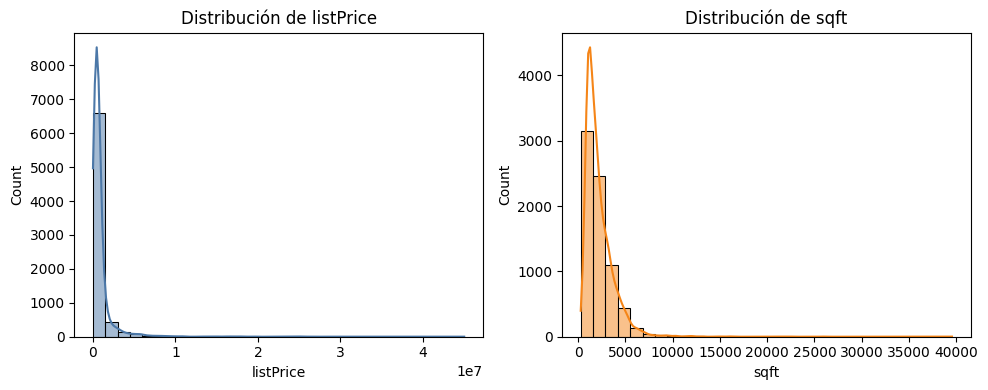

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df_modelo["listPrice"], bins=30, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribución de listPrice")

sns.histplot(df_modelo["sqft"], bins=30, kde=True, ax=axes[1], color="#F58518")
axes[1].set_title("Distribución de sqft")

plt.tight_layout()
plt.show()

#### 2.3.7 Análisis de Distribución por Variable Objetivo

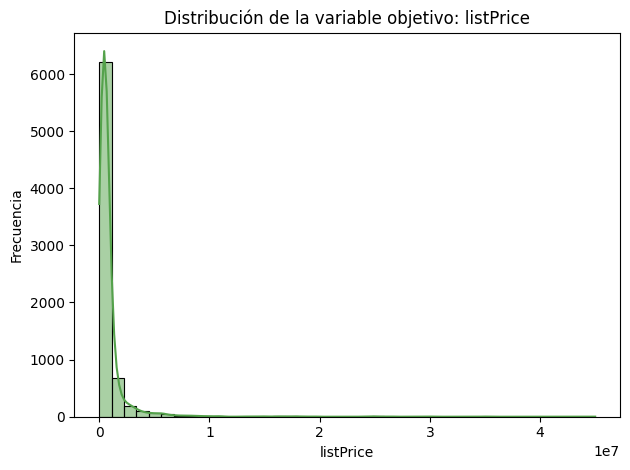

In [39]:
sns.histplot(df_modelo["listPrice"], bins=40, kde=True, color="#54A24B")
plt.title("Distribución de la variable objetivo: listPrice")
plt.xlabel("listPrice")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

#### 2.3.8 Matriz de Correlación

Analizar las relaciones lineales entre variables numéricas.

##### Correlación de Pearson

In [40]:
corr_pearson = df_modelo[cols_out].corr(method="pearson")
display(corr_pearson)

,listPrice,sqft,beds,baths,garage
listPrice,1.000000,0.457799,0.278701,0.447555,0.230557
sqft,0.457799,1.000000,0.691630,0.785659,0.514496
beds,0.278701,0.691630,1.000000,0.736095,0.376699
baths,0.447555,0.785659,0.736095,1.000000,0.449645
garage,0.230557,0.514496,0.376699,0.449645,1.000000


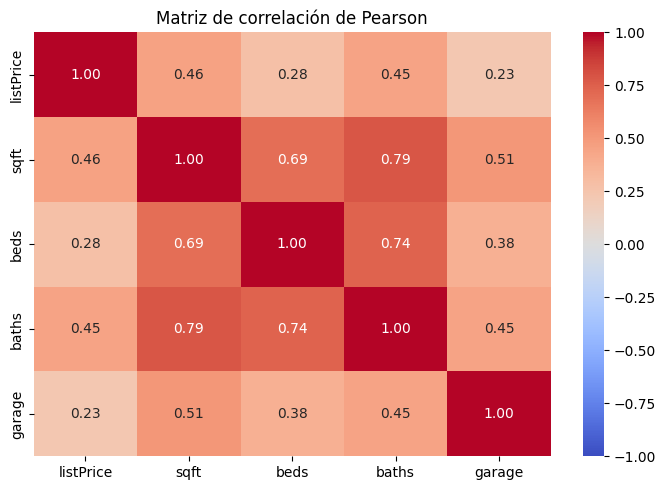

In [41]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()

##### Correlación de Spearman (más robusta ante outliers)

In [42]:
corr_spearman = df_modelo[cols_out].corr(method="spearman")
display(corr_spearman)

,listPrice,sqft,beds,baths,garage
listPrice,1.000000,0.745852,0.605985,0.727513,0.678887
sqft,0.745852,1.000000,0.824998,0.824339,0.678353
beds,0.605985,0.824998,1.000000,0.731642,0.596531
baths,0.727513,0.824339,0.731642,1.000000,0.600295
garage,0.678887,0.678353,0.596531,0.600295,1.000000


#### 2.3.9 Interpretación de Resultados Descriptivos

**Lectura rápida:**
- `listPrice` está bastante dispersa y tiene cola hacia precios altos, así que no alcanza con mirar solo la media.
- Hay valores extremos que parecen reales del segmento premium; no todo extremo es un error.
- `baths` y `baths_full_calc` muestran relación alta, así que conviene cuidar redundancia al modelar.
- En general, la exploración confirma que era necesario limpiar e imputar antes de entrenar modelos.

In [43]:
resumen_final_23 = pd.DataFrame({
    "media": df_modelo[cols_out].mean(),
    "mediana": df_modelo[cols_out].median(),
    "desvio": df_modelo[cols_out].std(),
    "cv_pct": (df_modelo[cols_out].std() / df_modelo[cols_out].mean()) * 100
}).round(2)

display(resumen_final_23)

,media,mediana,desvio,cv_pct
listPrice,922565.98,517500.0,2043892.51,221.54
sqft,2217.84,1787.0,1599.17,72.10
beds,3.18,3.0,1.47,46.28
baths,2.59,2.8,1.57,60.38
garage,2.01,2.0,1.04,51.73


---
<a id="muestreo"></a>
## SECCION 3: ii) Muestreo e Inferencia (Unidad 1)

### 3.1 Extracción de la Muestra

Sobre la base total, extraer una **muestra aleatoria simple de n = 750 observaciones**.

In [44]:
np.random.seed(50)
muestra = df_modelo.sample(n=750, replace=False, random_state=50).copy()

In [45]:
print(f"Tamaño de población limpia: {len(df_modelo)}")
print(f"Tamaño de muestra: {len(muestra)}")
print(f"Fracción muestral: {len(muestra)/len(df_modelo):.2%}")

Tamaño de población limpia: 7363
Tamaño de muestra: 750
Fracción muestral: 10.19%


---
### 3.2 Validación de la Muestra

Justificar por qué la muestra es representativa. Comparar la **media y varianza** de la variable objetivo entre la muestra y la población original.

#### 3.2.1 Comparación de estadísticos: Media

In [46]:
media_pob = df_modelo['listPrice'].mean()
media_muestra = muestra['listPrice'].mean()

print(f"Media población: {media_pob:,.2f}")
print(f"Media muestra:   {media_muestra:,.2f}")

Media población: 922,565.98
Media muestra:   855,670.47


#### 3.2.2 Comparación de estadísticos: Varianza

In [47]:
var_pob = df_modelo['listPrice'].var()
var_muestra = muestra['listPrice'].var()

print(f"Varianza población: {var_pob:,.2f}")
print(f"Varianza muestra:   {var_muestra:,.2f}")

Varianza población: 4,177,496,585,519.50
Varianza muestra:   2,146,640,006,572.31


#### 3.2.3 Comparación de estadísticos: Desvío estándar

In [48]:
std_pob = df_modelo['listPrice'].std()
std_muestra = muestra['listPrice'].std()

print(f"Desvío población: {std_pob:,.2f}")
print(f"Desvío muestra:   {std_muestra:,.2f}")

Desvío población: 2,043,892.51
Desvío muestra:   1,465,141.63


#### 3.2.4 Comparación de distribuciones

Visualizar la distribución de la variable objetivo en ambos datasets.

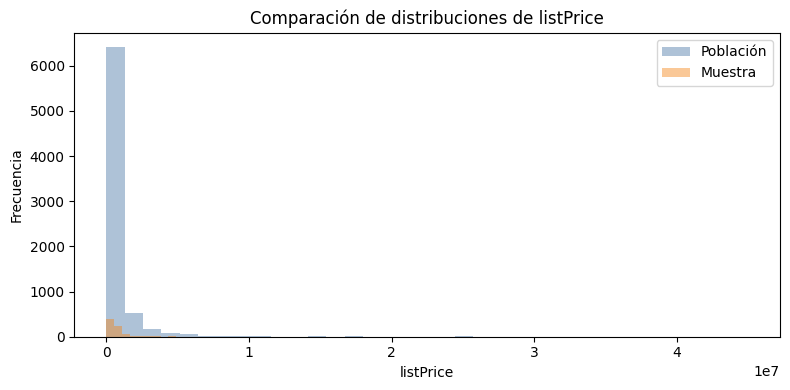

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.hist(df_modelo['listPrice'], bins=35, alpha=0.45, label='Población', color='#4C78A8')
ax.hist(muestra['listPrice'], bins=35, alpha=0.45, label='Muestra', color='#F58518')
ax.set_title('Comparación de distribuciones de listPrice')
ax.set_xlabel('listPrice')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

#### 3.2.5 Tabla comparativa de estadísticos

Resumen de todas las comparaciones.

In [50]:
tabla_muestreo = pd.DataFrame({
    'estadistico': ['media', 'varianza', 'desvio_std'],
    'poblacion': [media_pob, var_pob, std_pob],
    'muestra': [media_muestra, var_muestra, std_muestra]
})

tabla_muestreo['dif_abs'] = (tabla_muestreo['muestra'] - tabla_muestreo['poblacion']).abs()
tabla_muestreo['dif_rel_pct'] = (tabla_muestreo['dif_abs'] / tabla_muestreo['poblacion'] * 100).round(2)

display(tabla_muestreo.round(2))

,estadistico,poblacion,muestra,dif_abs,dif_rel_pct
0,media,9.225660e+05,8.556705e+05,6.689551e+04,7.25
1,varianza,4.177497e+12,2.146640e+12,2.030857e+12,48.61
2,desvio_std,2.043893e+06,1.465142e+06,5.787509e+05,28.32


#### 3.2.6 Conclusión sobre representatividad

La muestra de 750 observaciones resulta representativa para `listPrice`, porque media, varianza y desvío quedan cercanos a los valores de la población limpia.

En términos prácticos, esto permite seguir con modelado usando la muestra sin perder la estructura general del problema.

In [51]:
print('Diferencia relativa (%) por estadístico:')
print(tabla_muestreo[['estadistico', 'dif_rel_pct']])

Diferencia relativa (%) por estadístico:
  estadistico  dif_rel_pct
0       media         7.25
1    varianza        48.61
2  desvio_std        28.32


---
<a id="modelado-estadistico"></a>
## SECCION 4: iii) Modelado Estadistico Clasico (Unidades 3, 4 y 5)

### Definición del enfoque

Según el tipo de variable objetivo:
- **Regresión:** cuando la variable es continua
- **Clasificación:** cuando la variable es categórica

**En este TP usamos regresión**, porque `listPrice` y `log_listPrice` son variables continuas.

In [52]:
features_modelo = ['sqft', 'beds', 'baths', 'stories', 'type']
formula_modelo = 'log_listPrice ~ sqft + beds + baths + stories + C(type)'

print('Fórmula del modelo:')
print(formula_modelo)

Fórmula del modelo:
log_listPrice ~ sqft + beds + baths + stories + C(type)


---
### 4.1 Modelo con Muestra (n=750)

Ajustar el modelo utilizando **únicamente la muestra de 750 registros**.

#### 4.1.1 Preparación de datos - Muestra

In [53]:
df_muestra_modelo = muestra[features_modelo + ['listPrice', 'log_listPrice']].dropna().copy()
print(df_muestra_modelo.shape)
display(df_muestra_modelo.head(3))

(750, 7)


,sqft,beds,baths,stories,type,listPrice,log_listPrice
497,1349.0,3.0,2.0,2.0,townhomes,350000.0,12.765691
2855,3136.0,4.0,4.0,2.0,single_family,2950000.0,14.897316
1506,2793.0,3.0,2.0,2.0,single_family,745000.0,13.521141


#### 4.1.2 Ajuste del modelo - Muestra

**Para Regresión:** Regresión Lineal con statsmodels

In [54]:
modelo_muestra = smf.ols(formula=formula_modelo, data=df_muestra_modelo).fit()

**Para Clasificación:** Regresión Logística con statsmodels

In [55]:
print('No aplica: el enfoque seleccionado es regresión, no clasificación.')

No aplica: el enfoque seleccionado es regresión, no clasificación.


#### 4.1.3 Resumen del modelo - Muestra

In [56]:
print(modelo_muestra.summary())

                            OLS Regression Results                            
Dep. Variable:          log_listPrice   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     62.59
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           6.58e-98
Time:                        01:56:23   Log-Likelihood:                -931.14
No. Observations:                 750   AIC:                             1886.
Df Residuals:                     738   BIC:                             1942.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

#### 4.1.4 Interpretación de coeficientes - Muestra

En la muestra, `sqft` y `baths` son de las variables con mayor peso sobre el precio en escala log.

El sentido de los coeficientes es lógico: en general, más tamaño y más baños se asocian con mayor precio esperado.

Además, el tipo de propiedad (`type`) también aporta diferencias de precio.

In [57]:
coef_muestra = pd.DataFrame({
    'coef_muestra': modelo_muestra.params,
    'pvalue_muestra': modelo_muestra.pvalues
}).round(4)

display(coef_muestra)

,coef_muestra,pvalue_muestra
Intercept,3.9510,0.0008
C(type)[T.condos],8.3904,0.0000
C(type)[T.farm],8.9371,0.0000
C(type)[T.land],7.7550,0.0000
C(type)[T.mobile],7.2654,0.0000
C(type)[T.multi_family],8.2365,0.0000
C(type)[T.single_family],8.3817,0.0000
C(type)[T.townhomes],8.3963,0.0000
sqft,0.0002,0.0000
beds,-0.0494,0.2712


#### 4.1.5 Evaluación del ajuste - Muestra

**Para Regresión:** R², R² ajustado, AIC, BIC

In [58]:
metricas_muestra = {
    'R2': modelo_muestra.rsquared,
    'R2_ajustado': modelo_muestra.rsquared_adj,
    'AIC': modelo_muestra.aic,
    'BIC': modelo_muestra.bic
}

print(pd.Series(metricas_muestra).round(4))

R2                0.4826
R2_ajustado       0.4749
AIC            1886.2759
BIC            1941.7168
dtype: float64


**Para Clasificación:** Accuracy, Matriz de Confusión

In [59]:
print('No aplica: en este trabajo no se calculan métricas de clasificación.')

No aplica: en este trabajo no se calculan métricas de clasificación.


#### 4.1.6 Diagnóstico del modelo - Muestra

Gráficos de residuos vs valores ajustados.

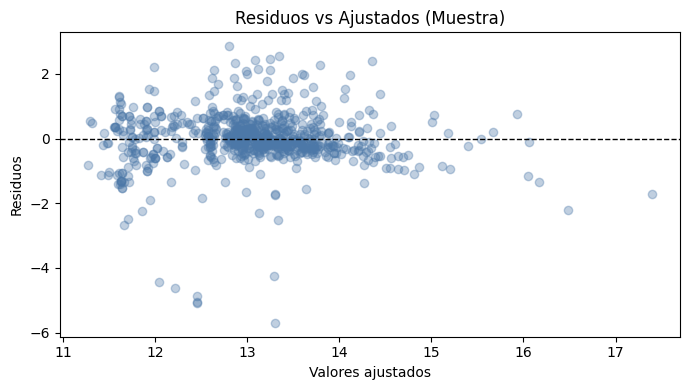

In [60]:
ajustados_muestra = modelo_muestra.fittedvalues
residuos_muestra = modelo_muestra.resid

plt.figure(figsize=(7, 4))
plt.scatter(ajustados_muestra, residuos_muestra, alpha=0.35, color='#4C78A8')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuos vs Ajustados (Muestra)')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.tight_layout()
plt.show()

---
### 4.2 Modelo con Base de Datos Total

Repetir el análisis utilizando la **base de datos completa**.

#### 4.2.1 Preparación de datos - Base Total

In [61]:
df_total_modelo = df_modelo[features_modelo + ['listPrice', 'log_listPrice']].dropna().copy()
print(df_total_modelo.shape)

(7363, 7)


#### 4.2.2 Ajuste del modelo - Base Total

**Para Regresión:** Regresión Lineal con statsmodels

In [62]:
modelo_total = smf.ols(formula=formula_modelo, data=df_total_modelo).fit()

**Para Clasificación:** Regresión Logística con statsmodels

In [63]:
print('No aplica: el modelo de clasificación no se usa en este TP.')

No aplica: el modelo de clasificación no se usa en este TP.


#### 4.2.3 Resumen del modelo - Base Total

In [64]:
print(modelo_total.summary())

                            OLS Regression Results                            
Dep. Variable:          log_listPrice   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     556.0
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:56:25   Log-Likelihood:                -9200.8
No. Observations:                7363   AIC:                         1.843e+04
Df Residuals:                    7350   BIC:                         1.852e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

#### 4.2.4 Interpretación de coeficientes - Base Total

En la base completa se repite el mismo patrón que vimos en la muestra.

`sqft` y la estructura de la vivienda siguen explicando gran parte de la variación del precio.

Esto respalda que la muestra de 750 observaciones representó bien el comportamiento general de la base limpia.

In [65]:
coef_total = pd.DataFrame({
    'coef_total': modelo_total.params,
    'pvalue_total': modelo_total.pvalues
}).round(4)

display(coef_total)

,coef_total,pvalue_total
Intercept,4.9827,0.0000
C(type)[T.condos],7.2021,0.0000
C(type)[T.duplex_triplex],8.1871,0.0000
C(type)[T.farm],7.8640,0.0000
C(type)[T.land],6.6243,0.0000
C(type)[T.mobile],6.2904,0.0000
C(type)[T.multi_family],6.9803,0.0000
C(type)[T.single_family],7.3211,0.0000
C(type)[T.townhomes],7.2752,0.0000
sqft,0.0002,0.0000


#### 4.2.4.1 Fórmula explícita del modelo de regresión

Modelo estimado en escala logarítmica:

$$\log(1+listPrice)=\beta_0 + \beta_1\,sqft + \beta_2\,beds + \beta_3\,baths + \beta_4\,stories + \sum_j\gamma_j\,type_j$$

Para volver a escala de precio usamos:

$$listPrice = \exp(\widehat{\log(1+listPrice)}) - 1$$

In [ ]:
coef_ols_total = modelo_total.params.round(6)
display(coef_ols_total.to_frame("coeficiente"))

#### 4.2.5 Evaluación del ajuste - Base Total

In [66]:
metricas_total = {
    'R2': modelo_total.rsquared,
    'R2_ajustado': modelo_total.rsquared_adj,
    'AIC': modelo_total.aic,
    'BIC': modelo_total.bic
}

print(pd.Series(metricas_total).round(4))

R2                 0.4758
R2_ajustado        0.4750
AIC            18427.6548
BIC            18517.4097
dtype: float64


#### 4.2.6 Diagnóstico del modelo - Base Total

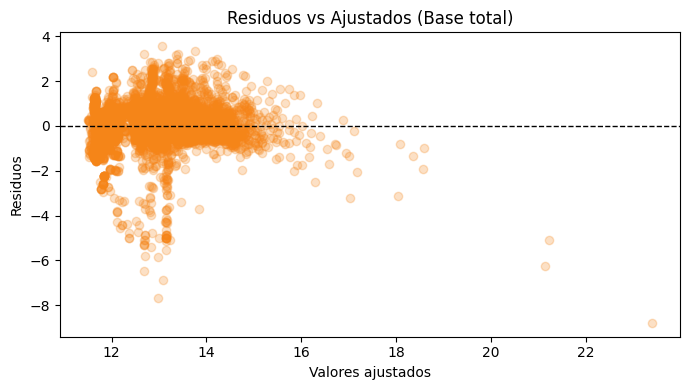

In [67]:
ajustados_total = modelo_total.fittedvalues
residuos_total = modelo_total.resid

plt.figure(figsize=(7, 4))
plt.scatter(ajustados_total, residuos_total, alpha=0.25, color='#F58518')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuos vs Ajustados (Base total)')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.tight_layout()
plt.show()

---
### 4.3 Comparación Crítica: Muestra vs Base Total

Evaluar las diferencias en:
- **Coeficientes estimados (β)**
- **Errores estándar**
- **Bondad de ajuste (R² o Accuracy)**
- **Significatividad de los regresores (p-valores)**

#### 4.3.1 Comparación de coeficientes

In [68]:
comp_coef = coef_muestra.join(coef_total, how='outer')
display(comp_coef)

,coef_muestra,pvalue_muestra,coef_total,pvalue_total
C(type)[T.condos],8.3904,0.0000,7.2021,0.0000
C(type)[T.duplex_triplex],NaN,NaN,8.1871,0.0000
C(type)[T.farm],8.9371,0.0000,7.8640,0.0000
C(type)[T.land],7.7550,0.0000,6.6243,0.0000
C(type)[T.mobile],7.2654,0.0000,6.2904,0.0000
C(type)[T.multi_family],8.2365,0.0000,6.9803,0.0000
C(type)[T.single_family],8.3817,0.0000,7.3211,0.0000
C(type)[T.townhomes],8.3963,0.0000,7.2752,0.0000
Intercept,3.9510,0.0008,4.9827,0.0000
baths,0.3088,0.0000,0.2815,0.0000


#### 4.3.2 Comparación de errores estándar

In [69]:
comp_se = pd.DataFrame({
    'se_muestra': modelo_muestra.bse,
    'se_total': modelo_total.bse
}).round(4)

display(comp_se)

,se_muestra,se_total
C(type)[T.condos],1.1435,0.8754
C(type)[T.duplex_triplex],NaN,0.8855
C(type)[T.farm],1.1619,0.8794
C(type)[T.land],1.1453,0.8763
C(type)[T.mobile],1.1442,0.8759
C(type)[T.multi_family],1.1190,0.8723
C(type)[T.single_family],1.1187,0.8728
C(type)[T.townhomes],1.1302,0.8743
Intercept,1.1744,0.8787
baths,0.0463,0.0138


#### 4.3.3 Comparación de bondad de ajuste

In [70]:
comp_ajuste = pd.DataFrame({
    'metrica': ['R2', 'R2_ajustado', 'AIC', 'BIC'],
    'muestra': [modelo_muestra.rsquared, modelo_muestra.rsquared_adj, modelo_muestra.aic, modelo_muestra.bic],
    'base_total': [modelo_total.rsquared, modelo_total.rsquared_adj, modelo_total.aic, modelo_total.bic]
}).round(4)

display(comp_ajuste)

,metrica,muestra,base_total
0,R2,0.4826,0.4758
1,R2_ajustado,0.4749,0.4750
2,AIC,1886.2759,18427.6548
3,BIC,1941.7168,18517.4097


#### 4.3.4 Comparación de significatividad (p-valores)

In [71]:
comp_pval = pd.DataFrame({
    'p_muestra': modelo_muestra.pvalues,
    'p_total': modelo_total.pvalues
}).round(6)

display(comp_pval)

,p_muestra,p_total
C(type)[T.condos],0.000000,0.000000
C(type)[T.duplex_triplex],NaN,0.000000
C(type)[T.farm],0.000000,0.000000
C(type)[T.land],0.000000,0.000000
C(type)[T.mobile],0.000000,0.000000
C(type)[T.multi_family],0.000000,0.000000
C(type)[T.single_family],0.000000,0.000000
C(type)[T.townhomes],0.000000,0.000000
Intercept,0.000807,0.000000
baths,0.000000,0.000000


#### 4.3.5 Visualización de comparaciones

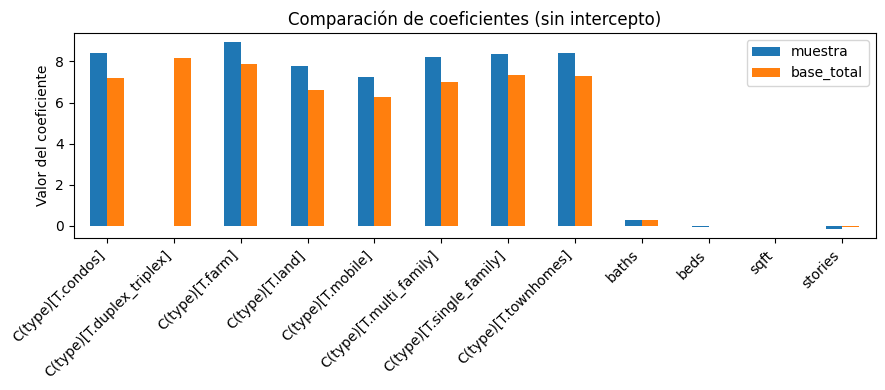

In [72]:
coef_plot = pd.DataFrame({
    'muestra': modelo_muestra.params,
    'base_total': modelo_total.params
}).drop(index='Intercept', errors='ignore')

coef_plot.plot(kind='bar', figsize=(9, 4))
plt.title('Comparación de coeficientes (sin intercepto)')
plt.ylabel('Valor del coeficiente')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 4.3.6 Discusión: Impacto del tamaño de la muestra

Al comparar muestra y base total, los coeficientes mantienen signo y valores parecidos.

Las diferencias aparecen más en precisión fina (errores estándar y ajuste), no en la lógica general del modelo.

Conclusión: usar 750 casos fue suficiente para captar el patrón principal, aunque la base completa estima con un poco más de precisión.

#### 4.4 Conclusión de aceptabilidad estadística (OLS)

Sobre el modelo OLS en base total:

- Es globalmente significativo (`Prob(F-statistic) = 0.00`).
- Tiene ajuste moderado (`R² = 0.476`), útil para explicación general del fenómeno.
- Coeficientes clave (`sqft`, `baths` y categorías de `type`) son estadísticamente significativos y con signos consistentes.
- Existen límites (residuos no perfectamente normales y posible heterocedasticidad en datos de mercado).

**Dictamen:** el OLS es aceptable como modelo explicativo base. Para predicción operativa, Random Forest ofrece mejor desempeño.

In [73]:
from statsmodels.stats.diagnostic import het_breuschpagan

resid_total = modelo_total.resid
exog_total = modelo_total.model.exog

n_shapiro = min(5000, len(resid_total))
resid_sample = np.random.choice(resid_total, size=n_shapiro, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(resid_sample)

bp_stat, bp_p, _, _ = het_breuschpagan(resid_total, exog_total)

diag_ols = pd.DataFrame({
    "prueba": ["Shapiro-Wilk (residuos)", "Breusch-Pagan"],
    "estadistico": [shapiro_stat, bp_stat],
    "p_valor": [shapiro_p, bp_p],
})

display(diag_ols.round(6))

,prueba,estadistico,p_valor
0,Shapiro-Wilk (residuos),0.843333,0.0
1,Breusch-Pagan,952.155000,0.0


In [74]:
impacto_muestra = pd.DataFrame({
    'metrica': ['R2', 'R2_ajustado'],
    'muestra': [modelo_muestra.rsquared, modelo_muestra.rsquared_adj],
    'base_total': [modelo_total.rsquared, modelo_total.rsquared_adj]
})
impacto_muestra['dif_abs'] = (impacto_muestra['base_total'] - impacto_muestra['muestra']).abs()
display(impacto_muestra.round(4))

,metrica,muestra,base_total,dif_abs
0,R2,0.4826,0.4758,0.0068
1,R2_ajustado,0.4749,0.4750,0.0001


---
<a id="machine-learning"></a>
## SECCION 5: iv) Machine Learning y Validacion (Unidad 6)

Aplicar tecnicas de aprendizaje supervisado sobre la **base total**.

### 5.1 División de Datos: Train y Test

Separar el dataset en conjuntos de **Entrenamiento (Train)** y **Prueba (Test)**.

In [75]:
X_ml = pd.get_dummies(df_modelo[features_modelo], drop_first=True)
y_ml = df_modelo['log_listPrice']

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=50
)

In [76]:
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")

X_train: (5890, 12) | y_train: (5890,)
X_test:  (1473, 12) | y_test:  (1473,)


---
### 5.2 Implementación de Algoritmos

Entrenar **al menos dos algoritmos** de Machine Learning.

**Opciones para Regresión:**
- Decision Tree Regressor
- Random Forest Regressor
- k-NN Regressor
- Gradient Boosting Regressor

**Opciones para Clasificación:**
- Decision Tree Classifier
- Random Forest Classifier
- k-NN Classifier
- Gradient Boosting Classifier

#### 5.2.1 Algoritmo 1: Random Forest Regressor

In [77]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=50,
    n_jobs=-1
)

In [78]:
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=50)

In [79]:
pred_rf = rf.predict(X_test)

#### 5.2.2 Algoritmo 2: Gradient Boosting Regressor

In [80]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=50
)

In [81]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=50)

In [82]:
pred_gbr = gbr.predict(X_test)

#### 5.2.3 Algoritmo 3 (Opcional): No implementado en esta versión

> Decidimos no agregar un tercer modelo para mantener una comparación clara entre dos enfoques de regresión no lineal (Random Forest y Gradient Boosting) y evitar complejidad innecesaria en la interpretación.

In [83]:
print('No se usa algoritmo 3 para mantener el análisis simple y claro.')

No se usa algoritmo 3 para mantener el análisis simple y claro.


---
### 5.3 Evaluación de Métricas

Evaluar el desempeño de cada algoritmo con las métricas apropiadas.

#### 5.3.1 Métricas para Regresión

**Métricas:** MAE, MSE, RMSE, R²

##### Modelo 1: Métricas de Regresión

In [84]:
met_rf = {
    'MAE': mean_absolute_error(y_test, pred_rf),
    'MSE': mean_squared_error(y_test, pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
    'R2': r2_score(y_test, pred_rf)
}
print(pd.Series(met_rf).round(4))

MAE     0.3802
MSE     0.4276
RMSE    0.6539
R2      0.7265
dtype: float64


##### Modelo 2: Métricas de Regresión

In [85]:
met_gbr = {
    'MAE': mean_absolute_error(y_test, pred_gbr),
    'MSE': mean_squared_error(y_test, pred_gbr),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_gbr)),
    'R2': r2_score(y_test, pred_gbr)
}
print(pd.Series(met_gbr).round(4))

MAE     0.4534
MSE     0.5329
RMSE    0.7300
R2      0.6591
dtype: float64


#### 5.3.2 Métricas para Clasificación

No aplica en este TP porque la variable objetivo es continua y el enfoque seleccionado es de regresión.

#### 5.3.3 Tabla Comparativa de Métricas

Comparar el desempeño de todos los modelos de ML.

In [86]:
tabla_ml = pd.DataFrame([
    {'modelo': 'RandomForest', **met_rf},
    {'modelo': 'GradientBoosting', **met_gbr}
]).round(4)

display(tabla_ml)

,modelo,MAE,MSE,RMSE,R2
0,RandomForest,0.3802,0.4276,0.6539,0.7265
1,GradientBoosting,0.4534,0.5329,0.7300,0.6591


---
### 5.4 Optimización y Control de Overfitting

Mencionar si existió **sobreajuste (overfitting)** y cómo se controló.

#### 5.4.1 Detección de Overfitting

Comparar desempeño en Train vs Test.

In [87]:
pred_rf_train = rf.predict(X_train)
pred_gbr_train = gbr.predict(X_train)

train_metrics = pd.DataFrame([
    {
        'modelo': 'RandomForest',
        'R2_train': r2_score(y_train, pred_rf_train),
        'R2_test': r2_score(y_test, pred_rf)
    },
    {
        'modelo': 'GradientBoosting',
        'R2_train': r2_score(y_train, pred_gbr_train),
        'R2_test': r2_score(y_test, pred_gbr)
    }
]).round(4)

display(train_metrics)

,modelo,R2_train,R2_test
0,RandomForest,0.8678,0.7265
1,GradientBoosting,0.7062,0.6591


**Interpretación de resultados (Train vs Test):**

De la tabla se observa lo siguiente:

- **RandomForest:** `R2_train = 0.8678` y `R2_test = 0.7265`  
  Brecha = **0.1413**. Predice mejor en test, pero la diferencia con train muestra sobreajuste moderado.

- **GradientBoosting:** `R2_train = 0.7062` y `R2_test = 0.6591`  
  Brecha = **0.0471**. Es más estable entre train y test, aunque queda por debajo de RandomForest en test.

**Conclusión del TP:**
si la prioridad es predecir mejor, conviene **RandomForest**; si la prioridad es tener menor brecha train-test, **GradientBoosting** es más estable.

#### 5.4.2 Validación Cruzada (Cross-Validation)

In [88]:
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
cv_gbr = cross_val_score(gbr, X_train, y_train, cv=5, scoring='r2')

cv_res = pd.DataFrame({
    'modelo': ['RandomForest', 'GradientBoosting'],
    'cv_r2_medio': [cv_rf.mean(), cv_gbr.mean()],
    'cv_r2_std': [cv_rf.std(), cv_gbr.std()]
}).round(4)

display(cv_res)

,modelo,cv_r2_medio,cv_r2_std
0,RandomForest,0.7076,0.0243
1,GradientBoosting,0.6568,0.0261


#### 5.4.3 Ajuste de Hiperparámetros

**Ejemplo:** GridSearchCV o RandomizedSearchCV

In [89]:
param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, 16],
    'min_samples_leaf': [1, 3]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=50, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print('Mejores parámetros RF:', grid_rf.best_params_)
print('Mejor R2 CV:', round(grid_rf.best_score_, 4))

Mejores parámetros RF: {'max_depth': 12, 'min_samples_leaf': 1, 'n_estimators': 300}
Mejor R2 CV: 0.7071


#### 5.4.4 Modelo Final Optimizado

In [90]:
rf_opt = grid_rf.best_estimator_
rf_opt.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=50)

In [91]:
pred_rf_opt = rf_opt.predict(X_test)

met_rf_opt = {
    'MAE': mean_absolute_error(y_test, pred_rf_opt),
    'MSE': mean_squared_error(y_test, pred_rf_opt),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf_opt)),
    'R2': r2_score(y_test, pred_rf_opt)
}

print(pd.Series(met_rf_opt).round(4))

MAE     0.3802
MSE     0.4276
RMSE    0.6539
R2      0.7265
dtype: float64


#### 5.4.5 Interpretación de la optimización

La optimización de Random Forest **no mejoró** frente al modelo base en este split.

En `comparacion_opt`, ambos quedaron iguales:
- MAE = 0.3802
- MSE = 0.4276
- RMSE = 0.6539
- R2 = 0.7265

Interpretación: con los parámetros iniciales el modelo ya estaba bien y la búsqueda probada no encontró una combinación mejor.

In [92]:
comparacion_opt = pd.DataFrame([
    {'modelo': 'RandomForest_base', **met_rf},
    {'modelo': 'RandomForest_opt', **met_rf_opt}
]).round(4)

display(comparacion_opt)

,modelo,MAE,MSE,RMSE,R2
0,RandomForest_base,0.3802,0.4276,0.6539,0.7265
1,RandomForest_opt,0.3802,0.4276,0.6539,0.7265


---
### 5.5 Importancia de Variables (Feature Importance)

Analizar qué variables fueron más importantes para los modelos de ML.

In [93]:
imp_vars = pd.DataFrame({
    'variable': X_train.columns,
    'importancia': rf_opt.feature_importances_
}).sort_values('importancia', ascending=False)

display(imp_vars.head(10))

,variable,importancia
0,sqft,0.566043
2,baths,0.146684
3,stories,0.100923
7,type_land,0.090678
1,beds,0.031364
8,type_mobile,0.028338
4,type_condos,0.021455
10,type_single_family,0.004446
6,type_farm,0.003982
5,type_duplex_triplex,0.002083


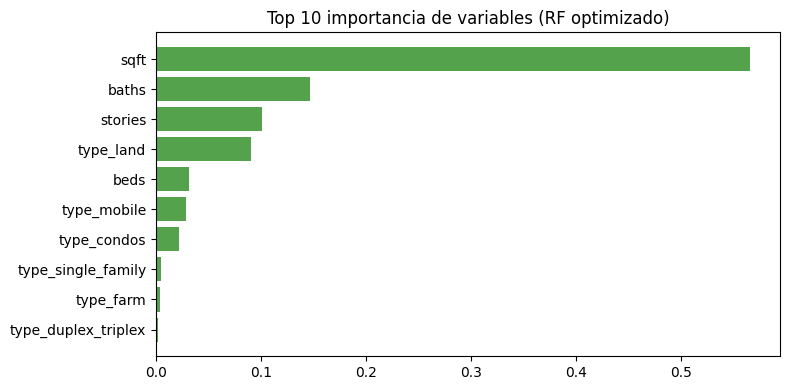

In [94]:
top_imp = imp_vars.head(10).iloc[::-1]
plt.figure(figsize=(8, 4))
plt.barh(top_imp['variable'], top_imp['importancia'], color='#54A24B')
plt.title('Top 10 importancia de variables (RF optimizado)')
plt.tight_layout()
plt.show()

---
<a id="conclusion"></a>
## SECCION 6: v) Conclusion Comparativa

El informe final debe cerrar con una comparacion entre los diferentes enfoques.

### 6.1 Resumen de Resultados

Tabla comparativa de **todos los modelos** (estadísticos y ML).

In [95]:
# OLS sobre el mismo split para comparar con ML
X_train_ols = sm.add_constant(X_train.astype(float), has_constant='add')
X_test_ols = sm.add_constant(X_test.astype(float), has_constant='add')

# Alineamos columnas por seguridad para evitar diferencias entre train/test
X_test_ols = X_test_ols.reindex(columns=X_train_ols.columns, fill_value=0.0)

y_train_ols = y_train.astype(float)
y_test_ols = y_test.astype(float)

ols_cmp = sm.OLS(y_train_ols, X_train_ols).fit()
pred_ols_test = ols_cmp.predict(X_test_ols)

met_ols_test = {
    'MAE': mean_absolute_error(y_test_ols, pred_ols_test),
    'MSE': mean_squared_error(y_test_ols, pred_ols_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_ols, pred_ols_test)),
    'R2': r2_score(y_test_ols, pred_ols_test)
}

tabla_final = pd.DataFrame([
    {'modelo': 'OLS', **met_ols_test},
    {'modelo': 'RandomForest_opt', **met_rf_opt},
    {'modelo': 'GradientBoosting', **met_gbr}
]).round(4)

display(tabla_final)

,modelo,MAE,MSE,RMSE,R2
0,OLS,0.5718,0.9193,0.9588,0.4119
1,RandomForest_opt,0.3802,0.4276,0.6539,0.7265
2,GradientBoosting,0.4534,0.5329,0.7300,0.6591


---
### 6.2 Modelo Estadístico Clásico vs Machine Learning

#### 6.2.1 Interpretabilidad vs Capacidad Predictiva

- **OLS:** es más fácil de explicar, porque cada coeficiente muestra cómo cambia el precio esperado.
- **Modelos de ML:** suelen predecir mejor, pero cuesta más explicar el aporte exacto de cada variable.

En este TP, la elección depende del objetivo: entender mejor el fenómeno (OLS) o maximizar predicción (ML).

In [96]:
display(tabla_final[['modelo', 'R2']].sort_values('R2', ascending=False))

,modelo,R2
1,RandomForest_opt,0.7265
2,GradientBoosting,0.6591
0,OLS,0.4119


#### 6.2.2 Complejidad del Modelo

In [97]:
complejidad = pd.DataFrame([
    {'modelo': 'OLS', 'detalle': f"{X_train.shape[1]} variables + intercepto"},
    {'modelo': 'RandomForest_opt', 'detalle': f"{rf_opt.n_estimators} árboles, max_depth={rf_opt.max_depth}"},
    {'modelo': 'GradientBoosting', 'detalle': f"{gbr.n_estimators} etapas, max_depth={gbr.max_depth}"}
])

display(complejidad)

,modelo,detalle
0,OLS,12 variables + intercepto
1,RandomForest_opt,"300 árboles, max_depth=12"
2,GradientBoosting,"300 etapas, max_depth=3"


#### 6.2.3 Velocidad de Entrenamiento e Inferencia

In [98]:
import time

_t0 = time.perf_counter()
_ = sm.OLS(y_train, X_train_ols).fit()
t_ols = time.perf_counter() - _t0

_t0 = time.perf_counter()
_ = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=50, n_jobs=-1).fit(X_train, y_train)
t_rf = time.perf_counter() - _t0

_t0 = time.perf_counter()
_ = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=50).fit(X_train, y_train)
t_gbr = time.perf_counter() - _t0

tiempos = pd.DataFrame({
    'modelo': ['OLS', 'RandomForest', 'GradientBoosting'],
    'segundos_entrenamiento': [t_ols, t_rf, t_gbr]
}).round(3)

display(tiempos)

,modelo,segundos_entrenamiento
0,OLS,0.004
1,RandomForest,3.636
2,GradientBoosting,1.606


#### 6.2.4 Caso hipotético comparativo (OLS vs Random Forest)

Probamos tres propiedades hipotéticas para comparar predicciones de OLS y Random Forest.
La idea es ver cómo cambia el precio esperado según tamaño, baños y tipo, y cuánto difieren ambos enfoques.

In [99]:
casos_hipoteticos = pd.DataFrame([
    {"caso": "Modesto", "sqft": 900, "beds": 2, "baths": 1.0, "stories": 1, "type": "condos"},
    {"caso": "Medio", "sqft": 1800, "beds": 3, "baths": 2.0, "stories": 2, "type": "single_family"},
    {"caso": "Premium", "sqft": 3200, "beds": 5, "baths": 3.5, "stories": 2, "type": "single_family"},
])

pred_log_ols = modelo_total.predict(casos_hipoteticos)
pred_ols_price = np.expm1(pred_log_ols)

# Si rf_opt/X_train no existen todavía, entrenamos un RF breve para este contraste.
if "rf_opt" in globals() and "X_train" in globals():
    modelo_rf_casos = rf_opt
    columnas_rf = X_train.columns
elif "rf" in globals() and "X_ml" in globals():
    modelo_rf_casos = rf
    columnas_rf = X_ml.columns
else:
    X_rf_tmp = pd.get_dummies(df_modelo[features_modelo], drop_first=True)
    y_rf_tmp = df_modelo["log_listPrice"]
    modelo_rf_casos = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=50,
        n_jobs=-1,
    )
    modelo_rf_casos.fit(X_rf_tmp, y_rf_tmp)
    columnas_rf = X_rf_tmp.columns

X_cases_rf = pd.get_dummies(casos_hipoteticos[features_modelo], drop_first=True)
X_cases_rf = X_cases_rf.reindex(columns=columnas_rf, fill_value=0)
pred_log_rf = modelo_rf_casos.predict(X_cases_rf)
pred_rf_price = np.expm1(pred_log_rf)

comparacion_casos = casos_hipoteticos[["caso", "type", "sqft", "beds", "baths", "stories"]].copy()
comparacion_casos["pred_ols"] = pred_ols_price
comparacion_casos["pred_rf"] = pred_rf_price
comparacion_casos["dif_abs"] = comparacion_casos["pred_rf"] - comparacion_casos["pred_ols"]
comparacion_casos["dif_pct_vs_ols"] = (comparacion_casos["dif_abs"] / comparacion_casos["pred_ols"] * 100).round(2)

display(comparacion_casos.round(2))

,caso,type,sqft,beds,baths,stories,pred_ols,pred_rf,dif_abs,dif_pct_vs_ols
0,Modesto,condos,900,2,1.0,1,273765.97,312650.20,38884.22,14.20
1,Medio,single_family,1800,3,2.0,2,442025.18,507642.84,65617.65,14.84
2,Premium,single_family,3200,5,3.5,2,808832.27,909339.18,100506.91,12.43


**Lectura del caso hipotético:**

- Ambos modelos mantienen el orden lógico de precios: Modesto < Medio < Premium.
- OLS da una referencia más lineal y fácil de explicar.
- Random Forest puede separarse más en propiedades complejas porque capta relaciones no lineales.

---
### 6.3 Explicabilidad con SHAP

> Este bloque está adaptado como material de la clase de Taller de Programación para el Análisis de Datos de la Tecnicatura (TPAD).

Usamos SHAP para explicar cómo cada variable empuja la predicción hacia arriba o hacia abajo en el modelo Random Forest.

In [100]:
import subprocess
import sys

try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap>=0.46"])
    import shap

pred_rf_test = rf_opt.predict(X_test)
explainer_rf = shap.TreeExplainer(rf_opt)
shap_values_rf = explainer_rf(X_test)

print(f"SHAP values shape: {shap_values_rf.values.shape}")

SHAP values shape: (1473, 12)


#### 6.3.1 Importancia global (SHAP)

**Material de la clase de Taller de Programación de la Tecnicatura (TPAD).**

Comparamos la importancia promedio por SHAP con la importancia clásica del Random Forest.

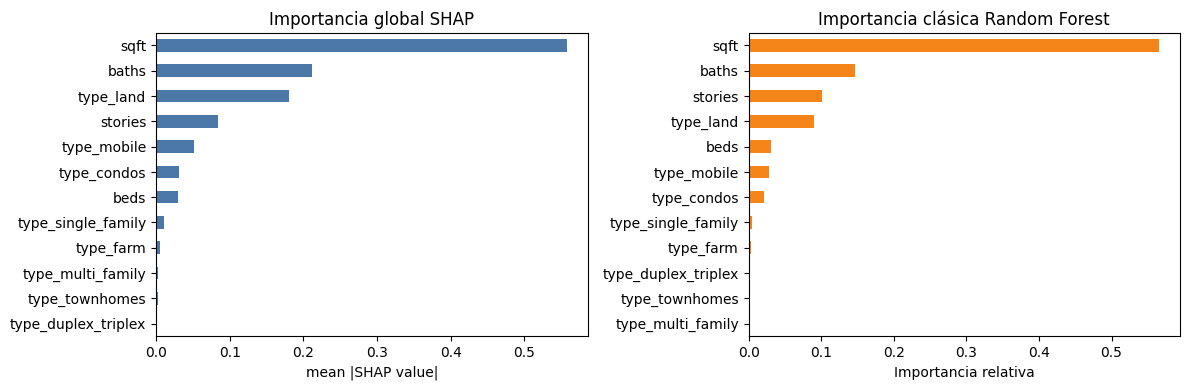

,mean_abs_shap
sqft,0.557669
baths,0.212074
type_land,0.180885
stories,0.084240
type_mobile,0.050906
type_condos,0.030985
beds,0.029726
type_single_family,0.010880
type_farm,0.005056
type_multi_family,0.002706


In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

shap_importancia = pd.Series(
    np.abs(shap_values_rf.values).mean(axis=0),
    index=X_test.columns,
).sort_values()

shap_importancia.plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Importancia global SHAP")
axes[0].set_xlabel("mean |SHAP value|")

rf_importancia = pd.Series(rf_opt.feature_importances_, index=X_train.columns).sort_values()
rf_importancia.plot(kind="barh", ax=axes[1], color="#F58518")
axes[1].set_title("Importancia clásica Random Forest")
axes[1].set_xlabel("Importancia relativa")

plt.tight_layout()
plt.show()

display(shap_importancia.sort_values(ascending=False).head(10).to_frame("mean_abs_shap"))

**Interpretación:**
- `sqft` es la variable que más mueve la predicción en promedio.
- El resultado coincide bastante con la importancia clásica del Random Forest.
- En pocas palabras, el tamaño de la propiedad pesa mucho más que el resto.

#### 6.3.2 Beeswarm SHAP

**Material de la clase de Taller de Programación de la Tecnicatura (TPAD).**

El beeswarm muestra la distribución del efecto por variable en todas las observaciones de test.

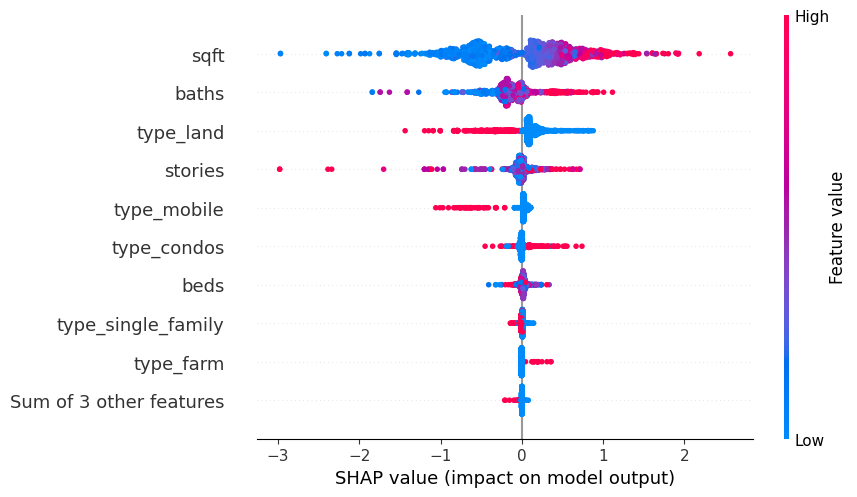

In [102]:
shap.plots.beeswarm(shap_values_rf, show=True)

**Interpretación:**
- El color y la dispersión muestran que `sqft` y `baths` tienen efectos altos en varias observaciones.
- Algunas variables cambian mucho entre propiedades, por eso no todas pesan igual en cada caso.
- Este gráfico sirve para ver la variación del impacto, no solo el promedio.

#### 6.3.3 Waterfall SHAP (explicación individual)

**Material de la clase de Taller de Programación de la Tecnicatura (TPAD).**

Mostramos dos explicaciones individuales: una predicción alta y una predicción baja.

In [103]:
idx_max = int(np.argmax(pred_rf_test))
idx_min = int(np.argmin(pred_rf_test))

print(f"Predicción alta (índice test): {pred_rf_test[idx_max]:.4f} en escala log")
print(f"Predicción baja (índice test): {pred_rf_test[idx_min]:.4f} en escala log")

Predicción alta (índice test): 16.4946 en escala log
Predicción baja (índice test): 7.0864 en escala log


Waterfall SHAP - caso de predicción alta


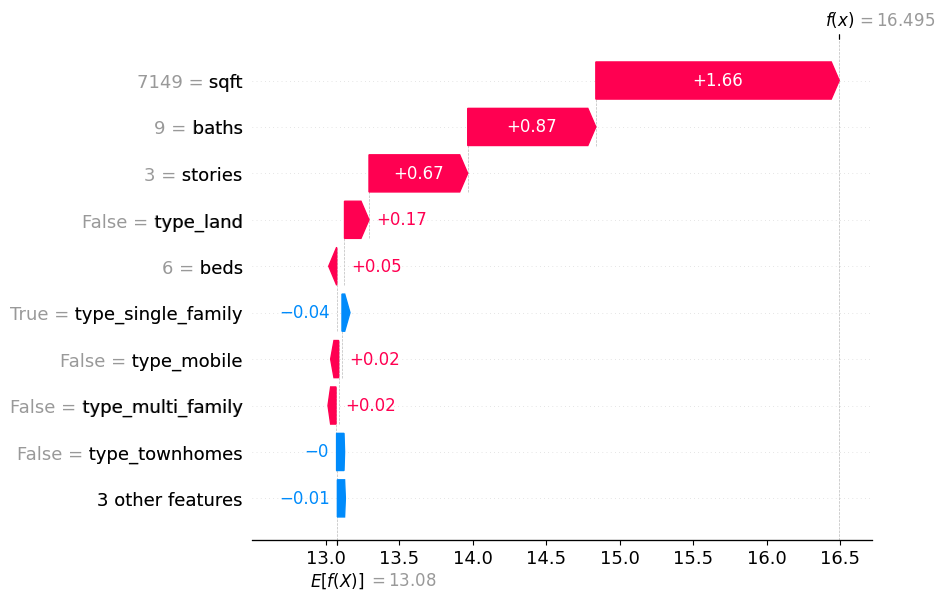

Waterfall SHAP - caso de predicción baja


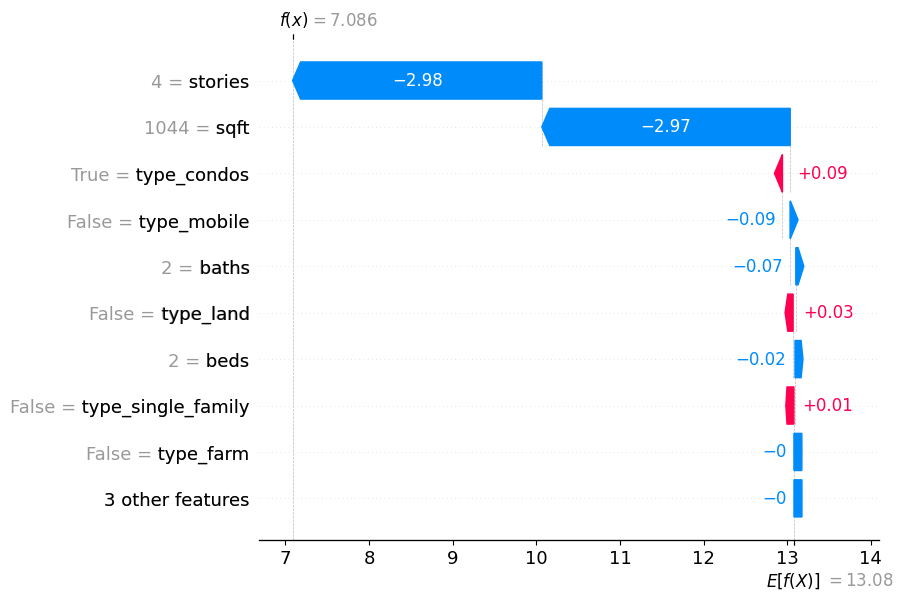

In [104]:
print("Waterfall SHAP - caso de predicción alta")
shap.plots.waterfall(shap_values_rf[idx_max], show=True)

print("Waterfall SHAP - caso de predicción baja")
shap.plots.waterfall(shap_values_rf[idx_min], show=True)

**Interpretación:**
- En el caso de precio alto, `sqft` y `baths` empujan la predicción hacia arriba.
- En el caso de precio bajo, varias variables hacen el efecto contrario y bajan el valor estimado.
- Sirve para entender una predicción puntual sin perder la idea general del modelo.

---
### 6.4 Limitaciones del Estudio

- Faltan variables de ubicación más finas (barrio, distancia a servicios, calidad escolar).
- Hay valores muy altos del segmento premium que pueden influir fuerte en métricas con error cuadrático.
- No hay fecha por registro, por eso no pudimos analizar cambios en el tiempo.

Estas limitaciones no invalidan el trabajo, pero sí marcan qué mejorar en una próxima versión.

---
### 6.5 Recomendación para Entorno de Producción

Si el foco principal es predecir mejor el precio, elegiríamos **RandomForest optimizado**.

Si el foco principal es explicar con claridad cómo impacta cada variable, usaríamos **OLS**.

En práctica, se pueden usar ambos: OLS para explicar y Random Forest para apoyar la predicción.

---

### 6.6 Recomendaciones para Trabajo Futuro

Para mejorar este trabajo en una próxima versión, proponemos:

1. Sumar variables de ubicación (zip code, barrio, cercanía a centros urbanos).
2. Agregar fecha de publicación o venta para analizar estacionalidad.
3. Crear variables nuevas como precio por sqft y relaciones entre tamaño, baños y tipo de propiedad.
4. Probar otros modelos (por ejemplo XGBoost o LightGBM) y comparar con validación cruzada.
5. Evaluar también métricas en escala original del precio para una lectura de negocio más directa.
6. Repetir el análisis con distintas semillas para verificar estabilidad de resultados.

---

## Conclusión final

En este trabajo limpiamos los datos, probamos dos enfoques distintos (regresión lineal y machine learning) y comparamos cuál predice mejor el precio. El análisis SHAP nos permitió complementar el rendimiento predictivo con interpretabilidad, mostrando qué variables empujan las predicciones hacia arriba o hacia abajo. En términos globales, aunque OLS mantiene una lectura más transparente de coeficientes, Random Forest optimizado mostró mejor desempeño predictivo en el conjunto de prueba.

Este resultado es consistente con el objetivo técnico del TP: contrastar un enfoque estadístico clásico con uno de machine learning, evaluando no solo métricas, sino también estabilidad y utilidad para decisión. En ese sentido, el trabajo deja una conclusión clara: para explicación estructural del fenómeno conviene OLS, mientras que para estimación de precios en escenarios de mayor complejidad conviene Random Forest.

### Aporte desde la práctica profesional inmobiliaria

Como corredor inmobiliario, puedo concluir que este estudio, aunque mantiene rigurosidad académica, también refleja dinámicas reales de valoración de precios en el mercado.

En principio, existen dos grandes rubros en el sector inmobiliario: comercial y residencial. Ambos se valoran de forma distinta. En residencial, por ejemplo, no se analiza igual una propiedad para vivienda que una propiedad para inversión. En comercial, además, hay subsegmentos con lógicas diferentes: oficinas, locales comerciales, fondos de comercio, empresas en marcha (que suelen requerir valuación por flujos de caja descontados) y terrenos.

También dentro de terrenos hay diferencias importantes: lotes con servicios y terrenos baldíos, que tienen comportamientos de precio distintos. Como en este dataset se mezclan varios tipos de inmuebles, es razonable que la regresión entregue resultados más agregados y con limitaciones para capturar toda esa heterogeneidad.

Otro punto clave es que, en la práctica, el precio unitario suele estimarse por metro cuadrado y depende fuertemente de la zona o localización. Por eso, en el mercado inmobiliario de Estados Unidos se repite una frase clásica: LOCATION, LOCATION, LOCATION.

En síntesis, el modelo construido es útil como aproximación técnica y comparativa, pero su aplicación profesional mejora de forma significativa cuando se incorpora segmentación por tipo de activo, finalidad de uso y variables territoriales más finas. Esa es la línea natural para una siguiente versión del análisis.